# TP1 : Algorithme EM et modèle de mélange gaussien

## G3 SDI - Introduction à l'Estimation Statistique

L'objectif de ce TP est d'implémenter l'algorithme EM pour estimer par maximum de vraisemblance les paramètres d'un modèle de mélange gaussien.

On utilisera le dataset *Old Faithful*, qui décrit 272 éruptions du geyser appelé Old Faithful du parc national de Yellowstone aux États-Unis. Chaque observation est constituée de 2 variables : la durée de l'éruption (en minutes) et le temps d'attente avant l'éruption (en minutes).

### Instructions

1. Renommez votre notebook sous la forme `tp1_Nom1_Nom2.ipynb`. 

2. Votre code et les résultats obtenus doivent être commentés !

3. Déposez votre notebook sur Moodle dans la section prévue à cet effet avant la date limite.

**Compte rendu — Ugo Roccamatisi.**


In [2]:
# Import necessary libraries
import numpy as np
from matplotlib import pyplot as plt
import scipy.stats as ss

**Q1**. Charger le dataset, normaliser puis visualiser les données. Commenter.

Dimensions : (272, 2) moyennes : [4.84906233e-16 4.40823848e-16] écarts-types : [1. 1.]


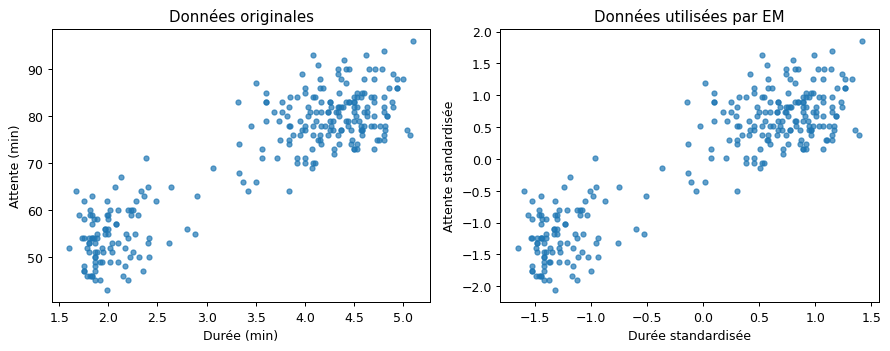

In [4]:
from pathlib import Path
# Les colonnes sont la durée (min) et le temps d'attente (min).
X_original=np.load(Path('oldfaithful.npy'))
mean_X=X_original.mean(axis=0);std_X=X_original.std(axis=0)
X=(X_original-mean_X)/std_X  # Standardisation par colonne.
print('Dimensions :',X.shape,'moyennes :',X.mean(axis=0),'écarts-types :',X.std(axis=0))
fig,axes=plt.subplots(1,2,figsize=(10,4))
axes[0].scatter(*X_original.T,s=16,alpha=.7);axes[0].set(xlabel='Durée (min)',ylabel='Attente (min)',title='Données originales')
axes[1].scatter(*X.T,s=16,alpha=.7);axes[1].set(xlabel='Durée standardisée',ylabel='Attente standardisée',title='Données utilisées par EM')
fig.tight_layout();plt.show()

**Réponse.** La standardisation met durée et attente à des échelles comparables. Le nuage présente deux zones de forte concentration, ce qui suggère d’essayer au moins deux composantes.

**Q2**. On note $\mathbf{x}_1,...,\mathbf{x}_n$ les données. On souhaite les modéliser par un modèle de mélange gaussien à $K$ composantes.

Écrire une fonction permettant de calculer la log-vraisemblance :
$$ \log \mathcal{L}(\theta;\mathbf{x}_1,...,\mathbf{x}_n) = \sum_{i=1}^n \log \left( \sum_{k=1}^K \pi_k \frac{1}{2 \pi \text{det}(\boldsymbol{\Sigma}_k)^{1/2}} \exp \left( \frac{1}{2} (\mathbf{x}_i - \boldsymbol{\mu}_k)^{\top} \boldsymbol{\Sigma}_k^{-1} (\mathbf{x}_i - \boldsymbol{\mu}_k) \right) \right), $$
avec $\theta = \{ \boldsymbol{\mu_1}, ..., \boldsymbol{\mu_K}, \boldsymbol{\Sigma}_1, ..., \boldsymbol{\Sigma}_K, \pi_1, ..., \pi_K \}$.

On pourra utiliser la fonction `multivariate_normal.pdf` de la librairie scipy.stats.

In [7]:
from scipy.special import logsumexp

def component_log_prob(X,mu,cov,p):
    """log[pi_k N(x_i|mu_k,Sigma_k)] : matrice n × K."""
    return np.column_stack([np.log(p[k])+ss.multivariate_normal.logpdf(X,mean=mu[k],cov=cov[k]) for k in range(len(p))])

def log_likelihood(X,mu,cov,p):
    # logsumexp évite le sous-flux des densités très petites.
    return float(np.sum(logsumexp(component_log_prob(X,mu,cov,p),axis=1)))

# Remarque : l'exposant de la densité normale dans l'énoncé doit porter un SIGNE MOINS.

**Q3**. Écrire une fonction qui implémente l'algorithme EM dans ce modèle, prenant pour arguments les données, le nombre de composantes $K$, et le nombre d'itérations de l'algorithme $N_{\text{iter}}$. Cette fonction retournera un tableau de taille $N_{\text{iter}} + 1$ contenant l'évolution des valeurs de la log-vraisemblance, ainsi que les valeurs finales des paramètres.

Initialisation des paramètres :
- Pour les moyennes, les $K$ premières observations du dataset ;
- Pour les matrices de covariances, la matrice identité ;
- $\pi_k = 1/K$ pour tout $k$.

In [9]:
def em_from_initialization(X,mu,cov,p,Niter,min_covar=1e-5):
    """Une itération E (responsabilités) puis M (paramètres) ; historique n_iter+1."""
    n,d=X.shape;K=len(p)
    history=np.empty(Niter+1);history[0]=log_likelihood(X,mu,cov,p)
    for i in range(Niter):
        # Étape E : r_ik = P(Z_i=k | x_i, theta).
        weighted_log=component_log_prob(X,mu,cov,p)
        responsibility=np.exp(weighted_log-logsumexp(weighted_log,axis=1,keepdims=True))
        # Étape M : moyenne pondérée de chaque groupe latent.
        Nk=responsibility.sum(axis=0)
        if np.any(Nk<1e-10):
            raise RuntimeError('Composante vide : relancer avec une autre initialisation')
        p=Nk/n
        mu=responsibility.T@X/Nk[:,None]
        centered=X[:,None,:]-mu[None,:,:]
        cov=np.einsum('nk,nki,nkj->kij',responsibility,centered,centered)/Nk[:,None,None]
        # Très faible stabilisation : garantit des covariances inversibles.
        cov+=min_covar*np.eye(d)[None,:,:]
        history[i+1]=log_likelihood(X,mu,cov,p)
    return history,mu,cov,p

def EM_algorithm_v1(X,K,Niter):
    n,d=X.shape
    if not 1<=K<=n:raise ValueError('K doit être entre 1 et n')
    mu=X[:K].copy();cov=np.repeat(np.eye(d)[None,:,:],K,axis=0)
    p=np.full(K,1/K)
    return em_from_initialization(X,mu,cov,p,Niter)

**Q4**. Faire tourner l'algorithme avec $K = 2$ et $N_{\text{iter}} = 50$.

Afficher l'évolution de la log-vraisemblance en fonction des itérations. Commenter.

Sur une même figure, afficher le dataset et représenter les estimations des deux lois normales du mélange à l'aide d'un *contour plot*. On pourra utiliser la fonction `plt.contour` (voir par exemple [ici](https://gist.github.com/gwgundersen/90dfa64ca29aa8c3833dbc6b03de44be)).

Log-vraisemblance initiale/finale : -745.817 -385.461
Poids : [0.644 0.356] centres standardisés :
 [[ 0.704  0.668]
 [-1.274 -1.21 ]]
Plus forte baisse (tolérance numérique) : -5.684341886080802e-14


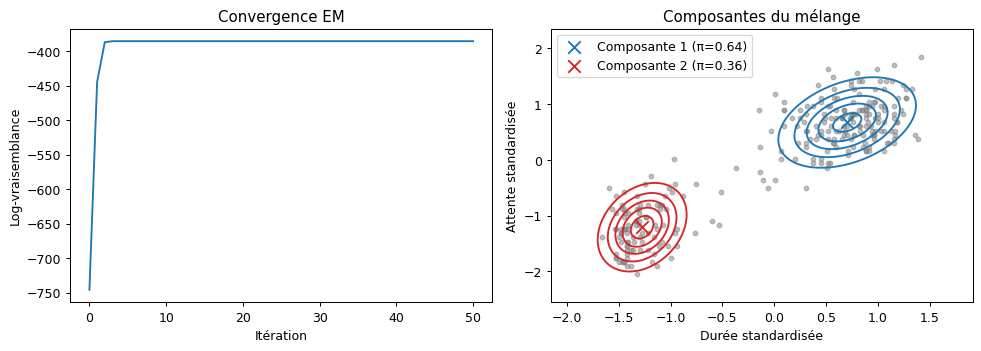

In [11]:
K=2;Niter=50
ll2,mu2,cov2,p2=EM_algorithm_v1(X,K,Niter)
print('Log-vraisemblance initiale/finale :',round(ll2[0],3),round(ll2[-1],3))
print('Poids :',np.round(p2,3),'centres standardisés :\n',np.round(mu2,3))
print('Plus forte baisse (tolérance numérique) :',np.diff(ll2).min())
fig,axes=plt.subplots(1,2,figsize=(11,4))
axes[0].plot(np.arange(Niter+1),ll2);axes[0].set(xlabel='Itération',ylabel='Log-vraisemblance',title='Convergence EM')
axes[1].scatter(*X.T,s=13,c='gray',alpha=.5)
xx,yy=np.meshgrid(np.linspace(X[:,0].min()-.5,X[:,0].max()+.5,160),np.linspace(X[:,1].min()-.5,X[:,1].max()+.5,160))
grid=np.c_[xx.ravel(),yy.ravel()]
for k,color in enumerate(['tab:blue','tab:red']):
    dens=ss.multivariate_normal.pdf(grid,mu2[k],cov2[k]).reshape(xx.shape)
    axes[1].contour(xx,yy,dens,levels=5,colors=color)
    axes[1].scatter(*mu2[k],c=color,marker='x',s=100,label=f'Composante {k+1} (π={p2[k]:.2f})')
axes[1].legend();axes[1].set(xlabel='Durée standardisée',ylabel='Attente standardisée',title='Composantes du mélange')
fig.tight_layout();plt.show()

**Réponse.** Pour K=2, la log-vraisemblance passe de −745,817 à −385,461 et se stabilise. Les deux poids estimés sont 0,644 et 0,356. Les centres se trouvent dans les deux amas du nuage. La baisse numérique minimale de l’historique (environ 5,7 × 10⁻¹⁴) correspond à un arrondi machine.


**Q5**. On souhaite maintenant étudier l'influence de l'initialisation sur les résultats. Modifier la fonction implémentant l'algorithme EM en y rajoutant un argument pour la graine aléatoire. Les paramètres seront maintenant initialisés de la manière suivante :
- $\boldsymbol{\mu}_k \sim \mathcal{N}(\mathbf{0},\mathbf{I}_2)$ ;
- $[\pi_1, ..., \pi_K]^{\top} \sim \text{Dirichlet}([1, ..., 1]^{\top})$ ;
- On gardera l'initialisation des matrices de covariance à la matrice identité.

In [14]:
def EM_algorithm_v2(X,K,Niter,seed):
    n,d=X.shape
    if not 1<=K<=n:raise ValueError('K doit être entre 1 et n')
    rng=np.random.default_rng(seed)
    mu=rng.normal(size=(K,d))  # N(0,I_d), indépendante par composante.
    cov=np.repeat(np.eye(d)[None,:,:],K,axis=0)
    p=rng.dirichlet(np.ones(K))
    return em_from_initialization(X,mu,cov,p,Niter)

**Q6**. On choisit maintenant $K=3$. Représenter l'évolution de la log-vraisemblance pour 10 graines aléatoires différentes. Commenter.

Afficher deux cas où la solution retournée par l'algorithme EM est visuellement différente. Commenter.

Quelle estimation de paramètres doit-on choisir ?

Minimum et maximum log L : [(3, np.float64(-381.839)), (2, np.float64(-374.411))]
Meilleure graine (maximum de log-vraisemblance) : 2


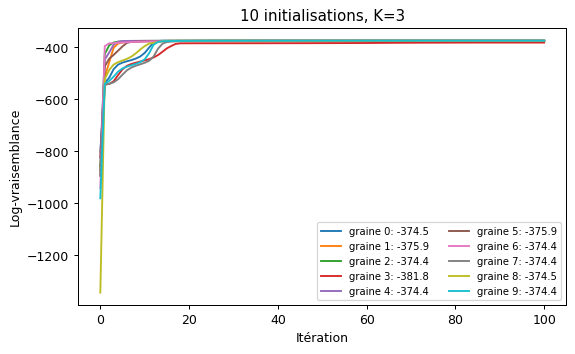

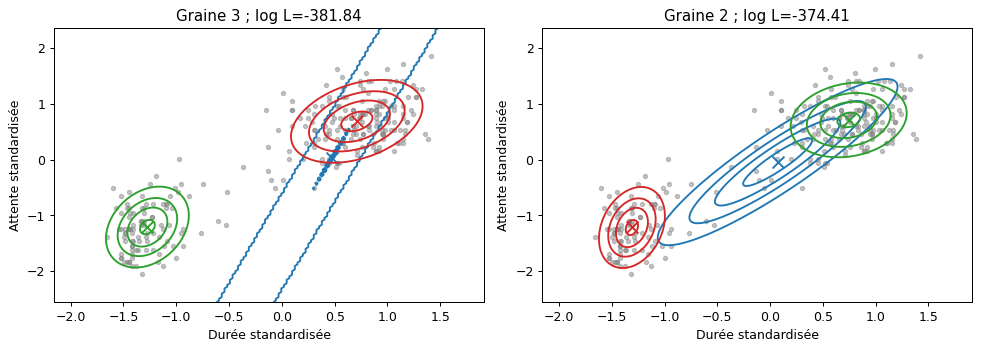

In [16]:
K=3;Niter=100
runs={seed:EM_algorithm_v2(X,K,Niter,seed) for seed in range(10)}
fig,ax=plt.subplots(figsize=(7,4))
for seed,(history,_,_,_) in runs.items():ax.plot(history,label=f'graine {seed}: {history[-1]:.1f}')
ax.set(xlabel='Itération',ylabel='Log-vraisemblance',title='10 initialisations, K=3');ax.legend(ncol=2,fontsize=8);plt.show()
ranking=sorted(runs,key=lambda seed:runs[seed][0][-1]);selected=[ranking[0],ranking[-1]]
fig,axes=plt.subplots(1,2,figsize=(11,4))
for ax,seed in zip(axes,selected):
    history,mu,cov,p=runs[seed]
    ax.scatter(*X.T,s=11,c='gray',alpha=.45)
    for k,color in enumerate(['tab:blue','tab:red','tab:green']):
        dens=ss.multivariate_normal.pdf(grid,mu[k],cov[k]).reshape(xx.shape)
        ax.contour(xx,yy,dens,levels=4,colors=color);ax.scatter(*mu[k],c=color,marker='x',s=90)
    ax.set(title=f'Graine {seed} ; log L={history[-1]:.2f}',xlabel='Durée standardisée',ylabel='Attente standardisée')
fig.tight_layout();plt.show()
print('Minimum et maximum log L :',[(s,round(runs[s][0][-1],3)) for s in selected])
print('Meilleure graine (maximum de log-vraisemblance) :',ranking[-1])

**Réponse.** Pour K=3, la graine 3 aboutit à une log-vraisemblance de −381,839, tandis que la graine 2 atteint −374,411 : EM peut rester dans un optimum local. Les représentations diffèrent aussi par la place des composantes, au-delà des simples permutations de couleurs. Pour ce K, on choisit la solution de plus grande log-vraisemblance, puis on compare les différents K avec le BIC.


**Q7**. On cherche maintenant à choisir la valeur optimale de $K$. Pour cela, on aimerait pouvoir comparer la vraisemblance des modèles obtenus avec différentes valeurs de $K$.

Cela peut se faire au travers d'un critère de sélection de modèle. Dans ce TP, nous étudierons le critère dit BIC :
$$ \text{BIC}(m) = k(m) \log(n) - 2 \log \mathcal{L}(m),$$
où $m$ est un modèle (ici donné par une valeur de $K$), $k(m)$ est le nombre de paramètres libres dans le modèle, $n$ le nombre d'échantillons, et $\mathcal{L}(m)$ le maximum de la fonction de vraisemblance de le modèle $m$. On sélectionne le modèle avec le plus faible BIC.

Montrer que $$k(m) = \frac{K}{2} (D+1)(D+2) - 1.$$

Comparer les valeurs de $K$ allant de 1 à 6. Quel est le modèle optimal d'après le critère BIC ?

K=1: paramètres=5, meilleure graine=0, log L=-544.99, BIC=1118.02
K=2: paramètres=11, meilleure graine=0, log L=-385.46, BIC=832.59
K=3: paramètres=17, meilleure graine=2, log L=-374.41, BIC=844.12
K=4: paramètres=23, meilleure graine=7, log L=-361.23, BIC=851.39
K=5: paramètres=29, meilleure graine=9, log L=-355.13, BIC=872.82
K=6: paramètres=35, meilleure graine=8, log L=-352.00, BIC=900.21
K retenu : 2


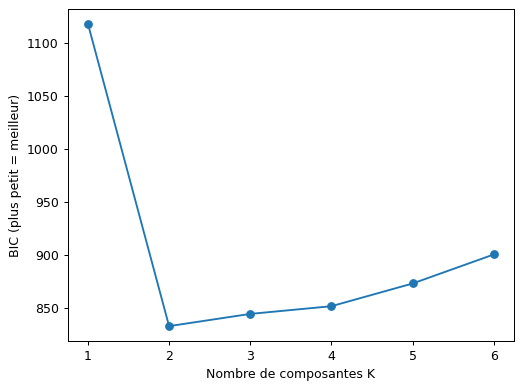

In [19]:
# Par composante : D moyennes + D(D+1)/2 termes de covariance symétrique.
# Il faut ajouter K-1 poids libres : K*(D+1)*(D+2)/2 - 1.
D=X.shape[1];n=len(X);ks=np.arange(1,7)
bic_values=[];best_runs={}
for K in ks:
    candidates=[]
    for seed in range(10):
        try:candidates.append((EM_algorithm_v2(X,K,120,seed),seed))
        except RuntimeError:pass  # Une initialisation a créé une composante vide.
    if not candidates:raise RuntimeError(f'Aucune solution pour K={K}')
    (trace,mu,cov,p),seed=max(candidates,key=lambda item:item[0][0][-1])
    n_params=K*(D+1)*(D+2)//2-1
    bic=n_params*np.log(n)-2*trace[-1]
    bic_values.append(bic);best_runs[K]=(trace,mu,cov,p,seed)
    print(f'K={K}: paramètres={n_params}, meilleure graine={seed}, log L={trace[-1]:.2f}, BIC={bic:.2f}')
fig,ax=plt.subplots();ax.plot(ks,bic_values,'o-');ax.set(xticks=ks,xlabel='Nombre de composantes K',ylabel='BIC (plus petit = meilleur)');plt.show()
print('K retenu :',int(ks[np.argmin(bic_values)]))

**Réponse.** En dimension D, une composante possède D moyennes et D(D+1)/2 éléments indépendants de covariance ; les K poids dont la somme vaut 1 ajoutent K−1 paramètres. Au total : K[D+D(D+1)/2]+K−1 = K(D+1)(D+2)/2−1. Le BIC minimal vaut **832,59 pour K=2**, devant 844,12 pour K=3 : le gain de vraisemblance obtenu avec une troisième composante ne compense pas ses paramètres supplémentaires.


**Question bonus**. Expliquer comment le modèle de mélange gaussien peut être utilisé pour du clustering.

**Réponse bonus.** Chaque observation reçoit les probabilités a posteriori `responsibility[i,k]` d’appartenir aux K groupes. On peut faire un regroupement souple avec ces probabilités ou affecter l’observation à la composante de probabilité maximale (`argmax`). Le numéro de groupe n’a pas d’interprétation intrinsèque.